IMPORTS

In [22]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

READ DATASET

In [23]:
features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

In [24]:
dataset = pd.read_csv('../data/credit_risk_dataset.csv')
X = dataset[features]
y = dataset["loan_status"]

SPLITTING TEST AND TRAIN SET

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

MISSING VALUES

In [26]:
dataset.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [27]:
# missing_value_fields =[
#     "person_emp_length",
#     "loan_int_rate"
# ]

In [28]:
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
# imputer.fit(X[missing_value_fields])
# X[missing_value_fields] = imputer.transform(X[missing_value_fields])

FEATURE SCALLING AND ENCODING

In [29]:
numerical_cols = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]
categorical_cols = [
    "person_home_ownership",
    "cb_person_default_on_file"
   
]
categorical_cols_with_label_encoding =[
     # no values , because label encoder is ment for y , dependent value not for independent value
]

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy='most_frequent')), 
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])
cat_pipeline_for_label_encoding = Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",LabelEncoder())
])

In [31]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),
    ("cat", cat_pipeline, categorical_cols),
    ("cat_labe;_encoder",cat_pipeline_for_label_encoding,categorical_cols_with_label_encoding)
])

In [32]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
# X=np.array(ct.fit_transform(X['person_home_ownership']))

In [33]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# X= le.fit_transform(X['cb_person_default_on_file'])

In [34]:
# from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)

MODEL

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    # ("model", SVC(kernel='rbf',random_state=0,probability=True,class_weight="balanced")) #0.8832555855634667
    # ("model", LogisticRegression(random_state=0)) #0.8498649643997054
    # ("model", GaussianNB()) #0.8098649643997054 - NOT GOOD
    # ("model", DecisionTreeClassifier(criterion="entropy",random_state=0)) #0.8626319666093788
    ("model",RandomForestClassifier(n_estimators = 200, criterion = 'entropy', random_state = 0, class_weight='balanced')) #0.902545323232
    # ("model", KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)) #0.8677878713479008
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy=...nt')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'cb_person_default_on_file']),
                                                 ('cat_labe;_encoder',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   LabelEncoder())]),
                                                  [])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy', n_estimators=200,
                                        random_state=0))])

TEST FOR EFFICIENCY

In [36]:
y_pred = pipeline.predict(X_test)
print(np.column_stack((y_pred, y_test)))

[[0 0]
 [0 0]
 [0 0]
 ...
 [0 0]
 [0 0]
 [1 1]]


In [37]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[6324  158]
 [ 636 1028]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6482
           1       0.87      0.62      0.72      1664

    accuracy                           0.90      8146
   macro avg       0.89      0.80      0.83      8146
weighted avg       0.90      0.90      0.90      8146



0.9025288485146084

In [38]:
dataset["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

VISUALIZATION

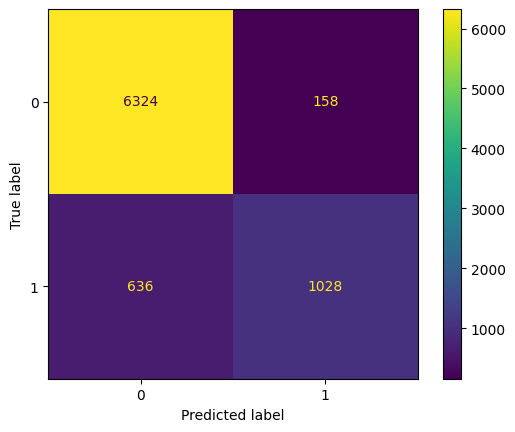

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

MANUAL TESTING

In [40]:
sample = pd.DataFrame([{
    "person_age": 22,
    "person_income": 900000,
    "person_home_ownership": "RENT",
    "person_emp_length": 2.5,
    "loan_amnt": 900000,
    "loan_int_rate": 8.5,
    "loan_percent_income": 0.332,   # EMI burden, not raw ratio
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 5
}])
sample_safe = pd.DataFrame([{
    "person_age": 32,
    "person_income": 120000,
    "person_home_ownership": "OWN",
    "person_emp_length": 8.0,
    "loan_amnt": 15000,
    "loan_int_rate": 7.5,
    "loan_percent_income": 0.12,
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 10
}])
#0 - SAFE  1 - RISKY
print(pipeline.predict(sample))
#Probability
prob=pipeline.predict_proba(sample)
print(prob)

[1]
[[0.11 0.89]]


In [41]:
dataset["loan_percent_income"].describe()

count    32581.000000
mean         0.170203
std          0.106782
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: loan_percent_income, dtype: float64

In [42]:
import joblib

joblib.dump(
    pipeline,
    "../model/loan_affordability_prediction_pipeline.pkl"
)

['../model/loan_affordability_prediction_pipeline.pkl']